In [4]:
import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import csv

In [5]:
## Set up file paths
## project root is two levels above notebooks/raw_data_processing
PROJECT_ROOT = Path.cwd().parent.parent
SHAPEFILE = PROJECT_ROOT / 'data' / 'raw' / 'fsa_boundary' / 'gfsa000a11a_e.shp'
SAVE_PATH = PROJECT_ROOT / 'data' / 'processed' / 'radon-concentration-cleaned.csv'
RADON_DATA = PROJECT_ROOT / 'data' / 'raw' / 'radon' / 'radon-concentration.csv'
FSA_BOUNDARY_PATH = PROJECT_ROOT / 'data' / 'processed' / 'fsa_centroids.csv'
RADON_CONCENTRATION_HEATMAP_PATH = PROJECT_ROOT / 'data' / 'processed' / 'radon_concentration_heatmap.html'

In [6]:
radon_df = pd.read_csv(RADON_DATA)[['ForwardSortationAreaCodes', 'TestDurationInDays', 'AverageRadonConcentrationInBqPerM3']]
radon_df.rename(columns={
    'ForwardSortationAreaCodes': 'FSA',
    'TestDurationInDays': 'n_days',
    'AverageRadonConcentrationInBqPerM3': 'concentration'
}, inplace=True)
radon_df.head()

,FSA,n_days,concentration
0,A0A,127.0,20
1,A0A,108.0,36
2,A0E,91.0,<15
3,A0A,91.0,31
4,A0C,98.0,26


In [7]:
radon_df['concentration'] = radon_df['concentration'].replace('<15', '7.5')
radon_df['concentration'] = pd.to_numeric(radon_df['concentration'], errors='coerce')

In [8]:
radon_df.to_csv(SAVE_PATH, index=False)

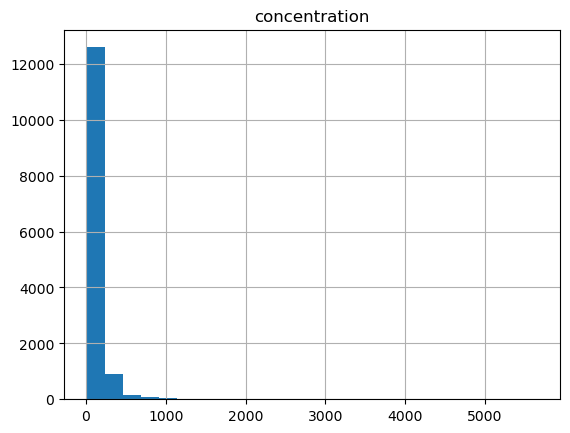

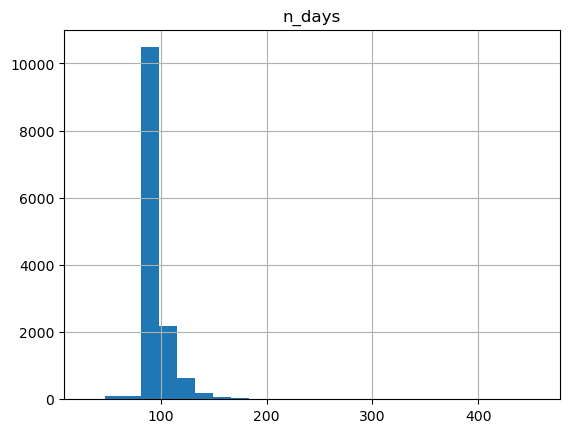

In [9]:
histogram = radon_df[['FSA','concentration']].hist(bins=25)
n_days_histogram = radon_df[['FSA','n_days']].hist(bins=25)

In [10]:
import folium
from folium.plugins import HeatMap
import pandas as pd

centroids_df = pd.read_csv(FSA_BOUNDARY_PATH)

centroids_df = centroids_df.merge(radon_df[['FSA', 'concentration']], on='FSA', how='left')
m = folium.Map(
    location=[56, -106],
    zoom_start=4,
    tiles='CartoDB positron'
)

heat_data = [
    [row['latitude'], row['longitude'], row['concentration']]
    for idx, row in centroids_df.iterrows()
    if pd.notna(row.get('concentration'))
]


HeatMap(
    heat_data,
    min_opacity=0.2,
    radius=30,
    blur=20,
    max_zoom=1,
    gradient={0.2: 'blue', 0.4: 'green', 0.6: 'yellow', 0.8: 'orange', 1.0: 'red'}
).add_to(m)

m.save(RADON_CONCENTRATION_HEATMAP_PATH)